# Sujet 4 — Risque d'une tranche senior de titrisation
**Risk Management — Monte-Carlo Challenges**  
Vivien Brunel — Serine Guichoud

---

### Hypothèses du modèle de Vasicek
- Portefeuille homogène et infiniment granulaire
- $PD = N(s) = 2\%$ → $s = N^{-1}(2\%) \approx -2.054$
- Corrélation d'actifs : $\rho \in [0, 100\%]$
- $LGD = 100\%$
- Seuils : $K = 2\%$ (question 2) et $K = 6\%$ (questions 3 & 4)

**Loi des pertes (Vasicek) :**  
Conditionnellement au facteur systémique $Z \sim \mathcal{N}(0,1)$, la perte du portefeuille est :
$$L(Z) = N\left(\frac{N^{-1}(PD) - \sqrt{\rho}\, Z}{\sqrt{1-\rho}}\right)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Paramètres globaux
PD   = 0.02                    # Probabilité de défaut moyenne
s    = norm.ppf(PD)            # s = N^{-1}(PD) ≈ -2.054
LGD  = 1.0                     # Loss Given Default = 100%

np.random.seed(42)             # Reproductibilité

print(f"PD    = {PD:.2%}")
print(f"s = N⁻¹(PD) = {s:.6f}")
print(f"LGD   = {LGD:.0%}")

PD    = 2.00%
s = N⁻¹(PD) = -2.053749
LGD   = 100%


In [2]:
def vasicek_loss(Z, rho, s=s):
    """
    Calcule la perte du portefeuille Vasicek conditionnellement au facteur Z.
    L(Z) = N( (N^{-1}(PD) - sqrt(rho) * Z) / sqrt(1 - rho) )
    
    Paramètres
    ----------
    Z   : array-like, réalisations du facteur systémique
    rho : float, corrélation d'actifs
    s   : float, N^{-1}(PD)
    """
    return norm.cdf((s - np.sqrt(rho) * Z) / np.sqrt(1 - rho))

---
## Question 1 — Vecteur de 10 000 pertes avec ρ = 25%

Nombre de simulations : 10,000
Corrélation ρ         : 25%
Perte moyenne simulée : 2.0138%  (théorique : 2.00%)
Perte max simulée     : 45.7448%
Perte min simulée     : 0.0002%


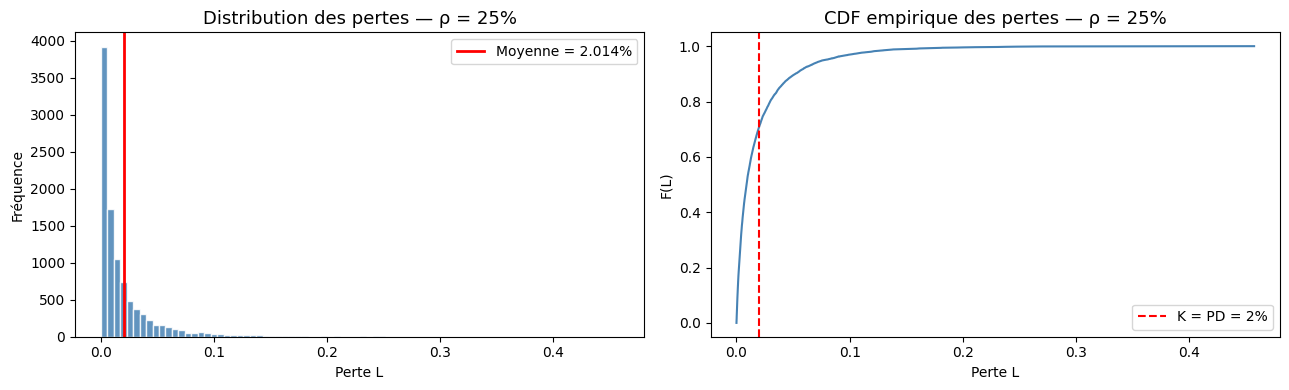

Figure sauvegardée : q1_distribution_pertes.png


In [3]:
N_sim_q1 = 10_000
rho_q1   = 0.25

# Simulation du facteur systémique
Z_q1 = np.random.standard_normal(N_sim_q1)

# Pertes du portefeuille
L_q1 = vasicek_loss(Z_q1, rho_q1)

print(f"Nombre de simulations : {N_sim_q1:,}")
print(f"Corrélation ρ         : {rho_q1:.0%}")
print(f"Perte moyenne simulée : {L_q1.mean():.4%}  (théorique : {PD:.2%})")
print(f"Perte max simulée     : {L_q1.max():.4%}")
print(f"Perte min simulée     : {L_q1.min():.4%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(L_q1, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(L_q1.mean(), color='red', lw=2, label=f'Moyenne = {L_q1.mean():.3%}')
axes[0].set_title('Distribution des pertes — ρ = 25%', fontsize=13)
axes[0].set_xlabel('Perte L'); axes[0].set_ylabel('Fréquence')
axes[0].legend()

axes[1].plot(np.sort(L_q1), np.linspace(0, 1, N_sim_q1), color='steelblue', lw=1.5)
axes[1].axvline(PD, color='red', lw=1.5, linestyle='--', label=f'K = PD = {PD:.0%}')
axes[1].set_title('CDF empirique des pertes — ρ = 25%', fontsize=13)
axes[1].set_xlabel('Perte L'); axes[1].set_ylabel('F(L)')
axes[1].legend()

plt.tight_layout()
plt.savefig('q1_distribution_pertes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : q1_distribution_pertes.png")

---
## Question 2 — Estimation Monte-Carlo avec K = 2% (= PD)

On estime :
1. **Perte attendue au-delà de K** : $E[L \cdot \mathbf{1}_{L > K}]$
2. **Probabilité de dépassement** : $P(L > K)$

et les **écarts-types** de ces estimateurs via la formule standard :  
$\hat{\sigma} = \frac{s_{\text{empirique}}}{\sqrt{n}}$

In [4]:
def monte_carlo_indicators(L, K):
    """
    Calcule les indicateurs Monte-Carlo pour un seuil K.
    
    Retourne
    --------
    EL_K    : E[L * 1_{L>K}]  — perte attendue au-delà de K
    std_EL  : écart-type de l'estimateur EL_K
    P_K     : P(L > K)        — probabilité de dépassement
    std_P   : écart-type de l'estimateur P_K
    """
    n          = len(L)
    indicator  = (L > K).astype(float)

    # Perte attendue au-delà de K
    values_EL  = L * indicator
    EL_K       = values_EL.mean()
    std_EL     = values_EL.std(ddof=1) / np.sqrt(n)

    # Probabilité de dépassement
    P_K        = indicator.mean()
    std_P      = indicator.std(ddof=1) / np.sqrt(n)

    return EL_K, std_EL, P_K, std_P


K2 = 0.02  # K = 2% = PD
EL2, std_EL2, P2, std_P2 = monte_carlo_indicators(L_q1, K2)

print("=" * 55)
print(f"  Seuil K = {K2:.0%}  |  ρ = {rho_q1:.0%}  |  n = {N_sim_q1:,}")
print("=" * 55)
print(f"  E[L · 1_{{L>K}}]  = {EL2:.6f}  ± {std_EL2:.6f}")
print(f"  P(L > K)        = {P2:.4%}        ± {std_P2:.4%}")
print("=" * 55)

  Seuil K = 2%  |  ρ = 25%  |  n = 10,000
  E[L · 1_{L>K}]  = 0.015596  ± 0.000332
  P(L > K)        = 29.2000%        ± 0.4547%


---
## Question 3 — K = 6%, variation de ρ de 0% à 100%

### Choix du nombre de simulations
Pour $K = 6\%$ et $\rho = 25\%$, on peut estimer $P(L > 6\%)$ analytiquement :
$$P(L > K) = N\!\left(\frac{N^{-1}(PD) - \sqrt{1-\rho}\, N^{-1}(K)}{\sqrt{\rho}}\right)$$
Ce qui donne une probabilité rare. Pour obtenir un coefficient de variation (CV) $\leq 5\%$, on utilise :
$$n \geq \frac{1}{p \cdot CV^2}$$

In [5]:
K3 = 0.06  # Seuil K = 6%

# Estimation analytique de P(L > K) via Vasicek
def vasicek_exceedance_prob(K, rho, PD=PD):
    """Probabilité analytique P(L > K) dans le modèle de Vasicek."""
    s_local = norm.ppf(PD)
    return norm.cdf((s_local - np.sqrt(1 - rho) * norm.ppf(K)) / np.sqrt(rho))

p_analytic = vasicek_exceedance_prob(K3, rho_q1)
print(f"P(L > {K3:.0%}) analytique (ρ=25%) ≈ {p_analytic:.4%}")

CV_target = 0.05  # 5% coefficient de variation
n_needed  = int(np.ceil(1 / (p_analytic * CV_target**2)))
print(f"Simulations minimales pour CV ≤ {CV_target:.0%} : {n_needed:,}")

# On choisit N_sim = 500 000 pour couvrir toutes les valeurs de ρ
N_sim_q3 = 500_000
print(f"→ Choix retenu : N_sim = {N_sim_q3:,}")

P(L > 6%) analytique (ρ=25%) ≈ 7.8600%
Simulations minimales pour CV ≤ 5% : 5,090
→ Choix retenu : N_sim = 500,000


In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# Vecteur du facteur systémique Z COMMUN pour toutes les valeurs de ρ
# Avantage : on ne simule Z qu'une seule fois → temps de calcul divisé par 101,
# et la variance inter-ρ due à l'aléa de simulation est éliminée
# (les courbes sont « lisses » et comparables).
# ──────────────────────────────────────────────────────────────────────────────
Z_common = np.random.standard_normal(N_sim_q3)

rho_values = np.arange(0.01, 1.00, 0.01)  # ρ de 1% à 99% (pas de 1%)

results_q3 = []

for rho in rho_values:
    L    = vasicek_loss(Z_common, rho)
    EL_K, std_EL, P_K, std_P = monte_carlo_indicators(L, K3)
    results_q3.append({
        'rho'    : rho,
        'EL_K'   : EL_K,
        'std_EL' : std_EL,
        'P_K'    : P_K,
        'std_P'  : std_P
    })

rhos     = np.array([r['rho']    for r in results_q3])
EL_Ks    = np.array([r['EL_K']   for r in results_q3])
std_ELs  = np.array([r['std_EL'] for r in results_q3])
P_Ks     = np.array([r['P_K']    for r in results_q3])
std_Ps   = np.array([r['std_P']  for r in results_q3])

print("Simulation terminée.")
print(f"Exemple ρ = 25% : E[L·1_{{L>{K3:.0%}}}] = {EL_Ks[24]:.5f}, P(L>{K3:.0%}) = {P_Ks[24]:.4%}")

Simulation terminée.
Exemple ρ = 25% : E[L·1_{L>6%}] = 0.00818, P(L>6%) = 7.8506%


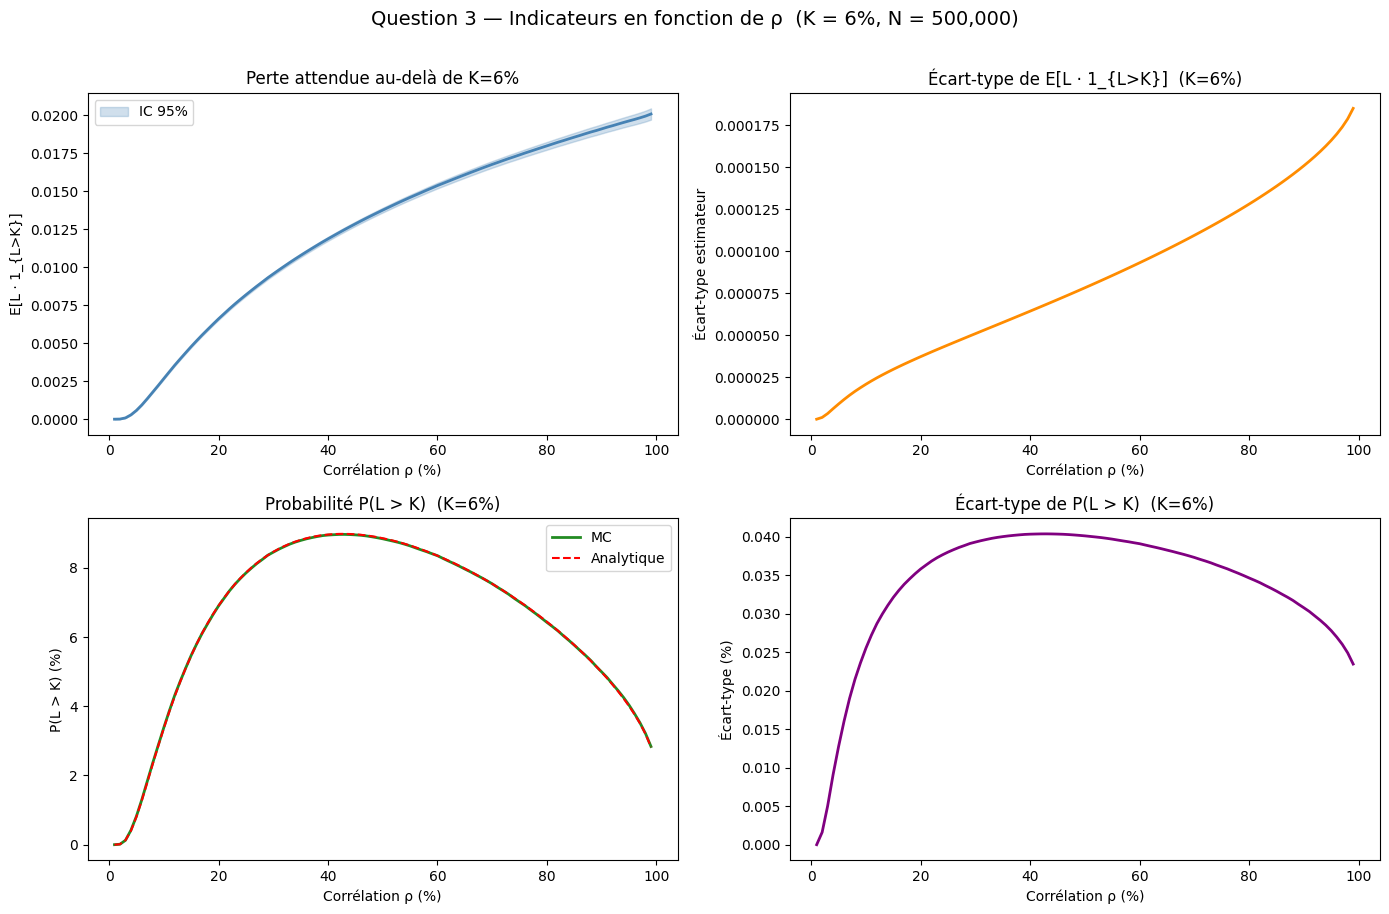

Figure sauvegardée : q3_indicateurs_vs_rho.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'Question 3 — Indicateurs en fonction de ρ  (K = {K3:.0%}, N = {N_sim_q3:,})', fontsize=14, y=1.01)

# 1. Perte attendue au-delà de K
ax = axes[0, 0]
ax.plot(rhos * 100, EL_Ks, color='steelblue', lw=2)
ax.fill_between(rhos * 100, EL_Ks - 2*std_ELs, EL_Ks + 2*std_ELs,
                alpha=0.25, color='steelblue', label='IC 95%')
ax.set_xlabel('Corrélation ρ (%)')
ax.set_ylabel('E[L · 1_{L>K}]')
ax.set_title(f'Perte attendue au-delà de K={K3:.0%}')
ax.legend()

# 2. Écart-type de l'estimateur EL_K
ax = axes[0, 1]
ax.plot(rhos * 100, std_ELs, color='darkorange', lw=2)
ax.set_xlabel('Corrélation ρ (%)')
ax.set_ylabel('Écart-type estimateur')
ax.set_title(f'Écart-type de E[L · 1_{{L>K}}]  (K={K3:.0%})')

# 3. Probabilité de dépassement
ax = axes[1, 0]
ax.plot(rhos * 100, P_Ks * 100, color='forestgreen', lw=2, label='MC')
# Courbe analytique Vasicek
P_analytic_curve = [vasicek_exceedance_prob(K3, r) for r in rhos]
ax.plot(rhos * 100, np.array(P_analytic_curve) * 100,
        color='red', lw=1.5, linestyle='--', label='Analytique')
ax.set_xlabel('Corrélation ρ (%)')
ax.set_ylabel('P(L > K) (%)')
ax.set_title(f'Probabilité P(L > K)  (K={K3:.0%})')
ax.legend()

# 4. Écart-type de P_K
ax = axes[1, 1]
ax.plot(rhos * 100, std_Ps * 100, color='purple', lw=2)
ax.set_xlabel('Corrélation ρ (%)')
ax.set_ylabel('Écart-type (%)')
ax.set_title(f'Écart-type de P(L > K)  (K={K3:.0%})')

plt.tight_layout()
plt.savefig('q3_indicateurs_vs_rho.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : q3_indicateurs_vs_rho.png")

**Commentaire — Avantage du vecteur Z commun :**

> En générant **un seul vecteur** $Z$ et en recalculant $L(Z, \rho)$ pour chaque $\rho$, on évite de simuler 101 × 500 000 tirages indépendants. Les courbes obtenues sont *lisses* car les fluctuations d'échantillonnage sont les mêmes pour tous les $\rho$ — elles se *compensent* sur les comparaisons inter-$\rho$. Cela revient à utiliser la même séquence quasi-aléatoire, ce qui est une forme de **réduction de variance par variables communes** (common random numbers).

---
## Question 4 — Réduction de variance

### 4a — Importance Sampling (IS)

Pour un événement rare $\{L > K\}$, on change la mesure de simulation en décalant le facteur $Z$ :
$$Z^* = Z - \mu \quad \text{avec} \quad Z \sim \mathcal{N}(\mu, 1)$$

Le poids de correction est :
$$w(Z) = \frac{f_{\mathcal{N}(0,1)}(Z)}{f_{\mathcal{N}(\mu,1)}(Z)} = e^{-\mu Z + \mu^2/2}$$

On choisit $\mu$ tel que $P(L > K | Z = \mu)$ soit maximisé — en pratique $\mu < 0$ car les grandes pertes arrivent pour de petites valeurs de $Z$ (facteur défavorable).

### 4b — Variable de contrôle

On utilise $L$ elle-même comme variable de contrôle, puisque $E[L] = PD$ est connu analytiquement :
$$\hat{\theta}_{CV} = \frac{1}{n}\sum_i \left(L_i \cdot \mathbf{1}_{L_i > K} - c(L_i - PD)\right)$$

Le coefficient optimal est :
$$c^* = \frac{\text{Cov}(L \cdot \mathbf{1}_{L>K},\; L)}{\text{Var}(L)}$$

In [8]:
def find_optimal_mu(K, rho, PD=PD):
    """
    Trouve le shift μ optimal pour l'importance sampling.
    On cherche Z_star tel que L(Z_star) = K, i.e. la « frontière » de l'événement rare.
    Le seuil optimal est le point de col de la densité tordue.
    """
    # L(Z) = K  ⟺  Z = (N^{-1}(PD) - sqrt(1-ρ)*N^{-1}(K)) / sqrt(ρ)
    s_local = norm.ppf(PD)
    if rho < 1e-8:
        return 0.0
    mu = (s_local - np.sqrt(1 - rho) * norm.ppf(K)) / np.sqrt(rho)
    return mu  # μ < 0 ⟹ on déplace Z vers les pertes élevées


def importance_sampling(Z_is, mu, rho, K, s=s):
    """
    Estimateur par Importance Sampling.
    Z_is ~ N(0,1), on simule sous N(μ,1) via Z_shifted = Z_is + μ.
    """
    Z_shifted = Z_is + mu                         # réalisations sous N(μ,1)
    L         = vasicek_loss(Z_shifted, rho, s)   # pertes
    weights   = np.exp(-mu * Z_shifted + mu**2 / 2)  # poids IS
    indicator = (L > K).astype(float)

    # E[L · 1_{L>K}]
    values_EL = L * indicator * weights
    EL_IS     = values_EL.mean()
    std_EL_IS = values_EL.std(ddof=1) / np.sqrt(len(Z_is))

    # P(L > K)
    values_P  = indicator * weights
    P_IS      = values_P.mean()
    std_P_IS  = values_P.std(ddof=1) / np.sqrt(len(Z_is))

    return EL_IS, std_EL_IS, P_IS, std_P_IS


def control_variate(Z, rho, K, PD=PD, s=s):
    """
    Estimateur par variable de contrôle.
    Variable de contrôle : L  (E[L] = PD connu)
    """
    L         = vasicek_loss(Z, rho, s)
    indicator = (L > K).astype(float)
    n         = len(Z)

    h     = L * indicator               # variable d'intérêt
    g     = L                           # variable de contrôle
    Eg    = PD                          # E[g] connu analytiquement

    # Coefficient optimal c*
    cov_hg = np.cov(h, g, ddof=1)[0, 1]
    var_g  = np.var(g, ddof=1)
    c_star = cov_hg / var_g if var_g > 0 else 0.0

    # Estimateur corrigé
    h_cv  = h - c_star * (g - Eg)
    EL_CV = h_cv.mean()
    std_EL_CV = h_cv.std(ddof=1) / np.sqrt(n)

    # Pour P(L>K) — variable de contrôle : indicator
    h2     = indicator
    cov2   = np.cov(h2, g, ddof=1)[0, 1]
    c2     = cov2 / var_g if var_g > 0 else 0.0
    h2_cv  = h2 - c2 * (g - Eg)
    P_CV   = h2_cv.mean()
    std_P_CV = h2_cv.std(ddof=1) / np.sqrt(n)

    return EL_CV, std_EL_CV, P_CV, std_P_CV


print("Fonctions IS et CV définies.")

Fonctions IS et CV définies.


In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# Comparaison MC brut / IS / CV  pour ρ variant de 1% à 99%
# ──────────────────────────────────────────────────────────────────────────────

N_sim_q4 = 100_000  # IS + CV convergent beaucoup plus vite : on réduit n
Z_q4     = np.random.standard_normal(N_sim_q4)   # vecteur commun

results_IS = []
results_CV = []

for rho in rho_values:
    mu = find_optimal_mu(K3, rho)

    EL_is, std_EL_is, P_is, std_P_is = importance_sampling(Z_q4, mu, rho, K3)
    results_IS.append({'rho': rho, 'EL_K': EL_is, 'std_EL': std_EL_is,
                        'P_K': P_is,  'std_P': std_P_is})

    EL_cv, std_EL_cv, P_cv, std_P_cv = control_variate(Z_q4, rho, K3)
    results_CV.append({'rho': rho, 'EL_K': EL_cv, 'std_EL': std_EL_cv,
                        'P_K': P_cv,  'std_P': std_P_cv})

std_EL_IS = np.array([r['std_EL'] for r in results_IS])
std_P_IS  = np.array([r['std_P']  for r in results_IS])
std_EL_CV = np.array([r['std_EL'] for r in results_CV])
std_P_CV  = np.array([r['std_P']  for r in results_CV])

# MC brut avec MÊME n pour comparaison équitable
results_MC_q4 = []
for rho in rho_values:
    L = vasicek_loss(Z_q4, rho)
    EL_K, std_EL, P_K, std_P = monte_carlo_indicators(L, K3)
    results_MC_q4.append({'std_EL': std_EL, 'std_P': std_P})

std_EL_MC4 = np.array([r['std_EL'] for r in results_MC_q4])
std_P_MC4  = np.array([r['std_P']  for r in results_MC_q4])

# Facteurs de réduction de variance
vrr_EL_IS = (std_EL_MC4 / std_EL_IS)**2
vrr_P_IS  = (std_P_MC4  / std_P_IS )**2
vrr_EL_CV = (std_EL_MC4 / std_EL_CV)**2
vrr_P_CV  = (std_P_MC4  / std_P_CV )**2

print(f"Simulation Q4 terminée (N = {N_sim_q4:,})")

Simulation Q4 terminée (N = 100,000)


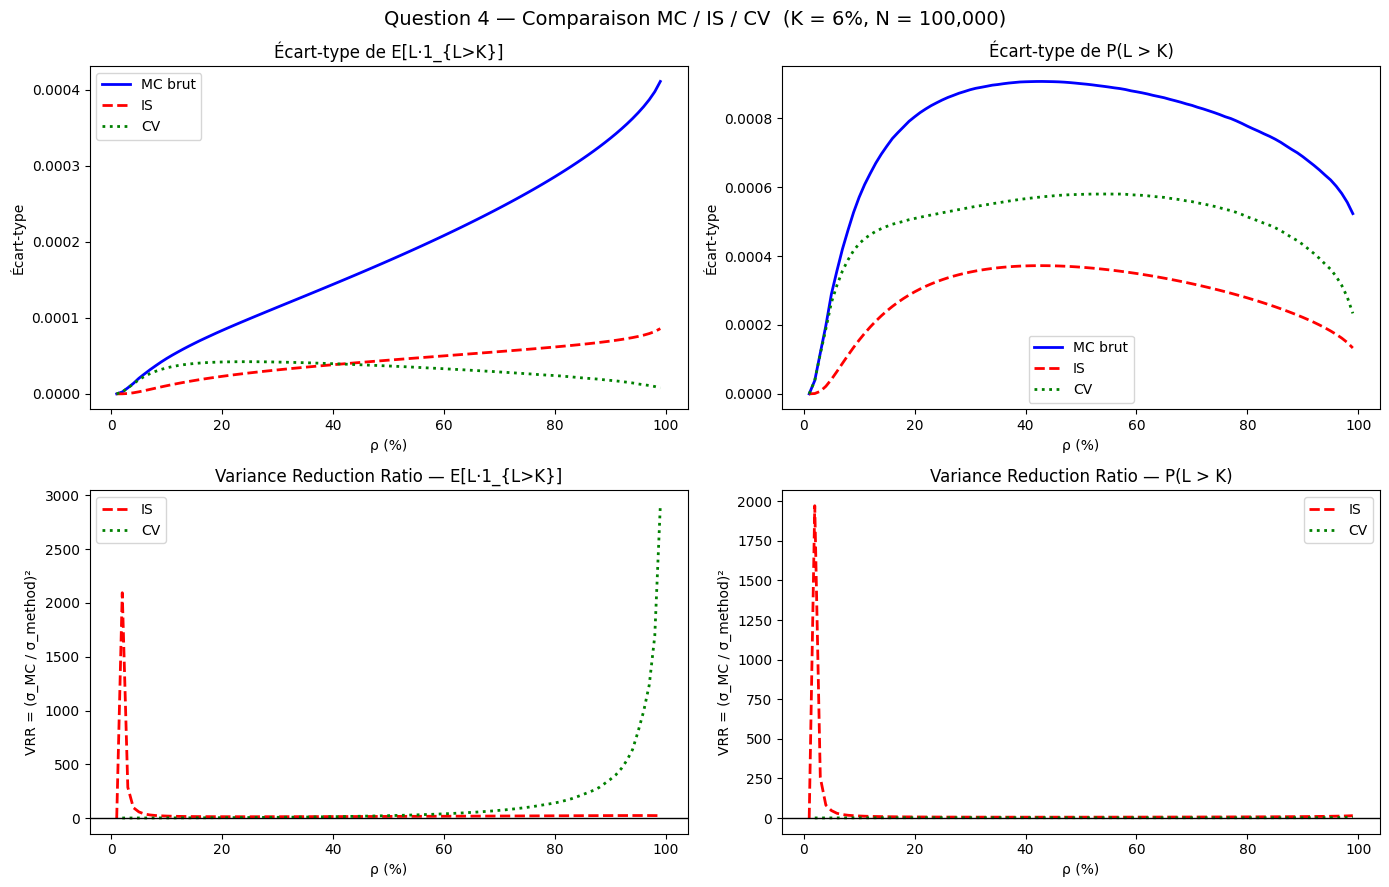

Figure sauvegardée : q4_reduction_variance.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'Question 4 — Comparaison MC / IS / CV  (K = {K3:.0%}, N = {N_sim_q4:,})', fontsize=14)

# ── Écart-type E[L·1_{L>K}] ──
ax = axes[0, 0]
ax.plot(rhos*100, std_EL_MC4, 'b-',  lw=2, label='MC brut')
ax.plot(rhos*100, std_EL_IS,  'r--', lw=2, label='IS')
ax.plot(rhos*100, std_EL_CV,  'g:',  lw=2, label='CV')
ax.set_xlabel('ρ (%)'); ax.set_ylabel('Écart-type')
ax.set_title('Écart-type de E[L·1_{L>K}]'); ax.legend()

# ── Écart-type P(L>K) ──
ax = axes[0, 1]
ax.plot(rhos*100, std_P_MC4, 'b-',  lw=2, label='MC brut')
ax.plot(rhos*100, std_P_IS,  'r--', lw=2, label='IS')
ax.plot(rhos*100, std_P_CV,  'g:',  lw=2, label='CV')
ax.set_xlabel('ρ (%)'); ax.set_ylabel('Écart-type')
ax.set_title('Écart-type de P(L > K)'); ax.legend()

# ── Variance Reduction Ratio E[L·1_{L>K}] ──
ax = axes[1, 0]
ax.plot(rhos*100, vrr_EL_IS, 'r--', lw=2, label='IS')
ax.plot(rhos*100, vrr_EL_CV, 'g:',  lw=2, label='CV')
ax.axhline(1, color='k', lw=1, linestyle='-')
ax.set_xlabel('ρ (%)'); ax.set_ylabel('VRR = (σ_MC / σ_method)²')
ax.set_title('Variance Reduction Ratio — E[L·1_{L>K}]'); ax.legend()

# ── Variance Reduction Ratio P(L>K) ──
ax = axes[1, 1]
ax.plot(rhos*100, vrr_P_IS, 'r--', lw=2, label='IS')
ax.plot(rhos*100, vrr_P_CV, 'g:',  lw=2, label='CV')
ax.axhline(1, color='k', lw=1, linestyle='-')
ax.set_xlabel('ρ (%)'); ax.set_ylabel('VRR = (σ_MC / σ_method)²')
ax.set_title('Variance Reduction Ratio — P(L > K)'); ax.legend()

plt.tight_layout()
plt.savefig('q4_reduction_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : q4_reduction_variance.png")

In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# Tableau de synthèse pour ρ = 25%
# ──────────────────────────────────────────────────────────────────────────────
idx = 24  # ρ = 25% (index 24 dans rho_values)

print("\n" + "=" * 65)
print(f"  SYNTHÈSE — ρ = {rhos[idx]:.0%},  K = {K3:.0%},  N = {N_sim_q4:,}")
print("=" * 65)
print(f"{'Méthode':<20} {'E[L·1_{{L>K}}]':>14}  {'σ(EL)':>12}  {'P(L>K)':>10}  {'σ(P)':>10}")
print("-" * 65)

L_tmp     = vasicek_loss(Z_q4, rhos[idx])
EL_mc, std_EL_mc, P_mc, std_P_mc = monte_carlo_indicators(L_tmp, K3)
print(f"{'MC brut':<20} {EL_mc:>14.6f}  {std_EL_mc:>12.6f}  {P_mc:>10.4%}  {std_P_mc:>10.4%}")

mu_opt = find_optimal_mu(K3, rhos[idx])
EL_is2, std_EL_is2, P_is2, std_P_is2 = importance_sampling(Z_q4, mu_opt, rhos[idx], K3)
print(f"{'IS (μ={mu_opt:.3f})':<20} {EL_is2:>14.6f}  {std_EL_is2:>12.6f}  {P_is2:>10.4%}  {std_P_is2:>10.4%}")

EL_cv2, std_EL_cv2, P_cv2, std_P_cv2 = control_variate(Z_q4, rhos[idx], K3)
print(f"{'CV':<20} {EL_cv2:>14.6f}  {std_EL_cv2:>12.6f}  {P_cv2:>10.4%}  {std_P_cv2:>10.4%}")

P_anal = vasicek_exceedance_prob(K3, rhos[idx])
print("-" * 65)
print(f"{'Analytique (P)':<20} {'N/A':>14}  {'N/A':>12}  {P_anal:>10.4%}  {'N/A':>10}")
print("=" * 65)
print(f"\nVRR IS  — E[L·1]: {(std_EL_mc/std_EL_is2)**2:.1f}x   P(L>K): {(std_P_mc/std_P_is2)**2:.1f}x")
print(f"VRR CV  — E[L·1]: {(std_EL_mc/std_EL_cv2)**2:.1f}x   P(L>K): {(std_P_mc/std_P_cv2)**2:.1f}x")


  SYNTHÈSE — ρ = 25%,  K = 6%,  N = 100,000
Méthode              E[L·1_{{L>K}}]         σ(EL)      P(L>K)        σ(P)
-----------------------------------------------------------------
MC brut                    0.008212      0.000099     7.9120%     0.0854%
IS (μ={mu_opt:.3f})        0.008143      0.000028     7.8205%     0.0332%
CV                         0.008125      0.000042     7.8468%     0.0526%
-----------------------------------------------------------------
Analytique (P)                  N/A           N/A     7.8600%         N/A

VRR IS  — E[L·1]: 12.9x   P(L>K): 6.6x
VRR CV  — E[L·1]: 5.5x   P(L>K): 2.6x


---
## Discussion — Extension à un portefeuille réel (hétérogène)

### Importance Sampling sur portefeuille hétérogène
Pour un portefeuille hétérogène (PD et expositions différentes par contrepartie $i$), le facteur systémique $Z$ reste le levier naturel. On choisit $\mu$ tel que la perte *attendue* sous la mesure tordue soit égale à $K$ :
$$\sum_i w_i \cdot PD_i^\mu = K \quad \text{où} \quad PD_i^\mu = N\!\left(\frac{N^{-1}(PD_i) - \sqrt{\rho_i}\,\mu}{\sqrt{1-\rho_i}}\right)$$
On résout en $\mu$ par dichotomie. Cette approche est parfaitement transposable (Glasserman et al., 2005).

### Variable de contrôle sur portefeuille hétérogène
La perte totale $L = \sum_i w_i L_i$ peut être utilisée comme variable de contrôle si son espérance $E[L] = \sum_i w_i PD_i$ est connue (ce qui est le cas). Le coefficient optimal $c^*$ se calcule de la même manière par régression empirique. La réduction de variance est d'autant plus forte que la corrélation entre $L \cdot \mathbf{1}_{L>K}$ et $L$ est élevée, ce qui est généralement vrai pour des seuils $K$ proches de la moyenne.